# ECON 611 Project: Does Okun's Law Still Hold in the U.S.?

**Research question:** Does Okun's Law still hold in the United States over the last 20 years (2005 Q1 – 2024 Q4)?

**Expected result:** A negative relationship between economic growth and unemployment. When real GDP grows faster, the unemployment rate should fall.

**What would support or contradict it:** A negative and statistically significant slope would support the expectation. A positive slope, or a slope that is not statistically significant, would contradict it.

## 1. Setup

This notebook pulls data from the FRED API with the `fredapi` package. It needs a free FRED API key stored in the `FRED_API_KEY` environment variable. The key is read from the environment and is never printed or saved in this notebook.

To set it before launching Jupyter (in Terminal):

```
export FRED_API_KEY="your_key_here"
```

In [9]:
import os

import matplotlib.pyplot as plt
import pandas as pd
import statsmodels.formula.api as smf
from fredapi import Fred

# Fetch from 2004 so the 2005 Q1 changes can be calculated.
FETCH_START = "2004-01-01"
FETCH_END = "2024-12-31"

# Analysis window: 2005 Q1 through 2024 Q4 (quarter-start dates).
ANALYSIS_START = "2005-01-01"
ANALYSIS_END = "2024-10-01"

COVID_QUARTERS = pd.to_datetime(["2020-04-01", "2020-07-01"])  # 2020 Q2, Q3

## 2. Fetch the data from FRED

Two FRED series are used:

- **UNRATE**: U.S. unemployment rate, monthly, percent, seasonally adjusted.
- **GDPC1**: U.S. real gross domestic product, quarterly, billions of chained 2017 dollars, seasonally adjusted annual rate.

Data are fetched from January 2004 through December 2024. The 2004 data are only used so the changes for 2005 Q1 can be calculated.

In [20]:
import os
from getpass import getpass
os.environ["FRED_API_KEY"]  = getpass("Paste your FRED key:").strip()

In [21]:
api_key = os.environ.get("FRED_API_KEY")
if not api_key:
    raise RuntimeError("Set the FRED_API_KEY environment variable before running this notebook.")

fred = Fred(api_key=api_key)
unrate = fred.get_series("UNRATE", observation_start=FETCH_START, observation_end=FETCH_END)
gdp = fred.get_series("GDPC1", observation_start=FETCH_START, observation_end=FETCH_END)

print(f"UNRATE: {len(unrate)} monthly observations")
print(f"GDPC1:  {len(gdp)} quarterly observations")

UNRATE: 252 monthly observations
GDPC1:  84 quarterly observations


## 3. Clean the data

1. **Convert unemployment to quarterly** by averaging the three months in each quarter. GDP is only reported quarterly, so the analysis is quarterly.
2. **Merge** the unemployment and GDP data by quarter.
3. **GDP growth** = (GDP this quarter / GDP last quarter − 1) × 100. This is the quarter-over-quarter percent change, *not* annualized.
4. **Change in unemployment** = unemployment rate this quarter − unemployment rate last quarter, in percentage points.
5. **Keep 2005 Q1 through 2024 Q4** and remove any missing values. This should leave 80 quarters.

In [15]:
import os
os.environ["FRED_API_KEY"] = "" 


In [22]:
# Monthly unemployment -> quarterly by averaging the three months in each quarter.
unrate_q = unrate.resample("QS").mean()

# Merge by quarter.
df = pd.concat({"unrate": unrate_q, "gdp": gdp}, axis=1)

# Quarter-over-quarter GDP growth (percent, not annualized)
# and change in the unemployment rate (percentage points).
df["gdp_growth"] = df["gdp"].pct_change() * 100
df["d_unrate"] = df["unrate"].diff()

# Keep the analysis window and drop missing values.
df = df.loc[ANALYSIS_START:ANALYSIS_END].dropna()
print(f"Observations: {len(df)} ({df.index[0].date()} to {df.index[-1].date()})")
df.head()

Observations: 80 (2005-01-01 to 2024-10-01)


,unrate,gdp,gdp_growth,d_unrate
2005-01-01,5.300000,15844.727,1.109363,-0.133333
2005-04-01,5.100000,15922.782,0.492624,-0.200000
2005-07-01,4.966667,16047.587,0.783814,-0.133333
2005-10-01,4.966667,16136.734,0.555517,0.000000
2006-01-01,4.733333,16353.835,1.345384,-0.233333


## 4. Regression: full sample

Simple OLS regression of the change in the unemployment rate on GDP growth:

$$\Delta u_t = a + b \times \text{GDP growth}_t + \varepsilon_t$$

The slope **b** is in *percentage points of unemployment per percentage point of quarterly GDP growth*. A negative b means faster growth goes with falling unemployment.

In [23]:
model = smf.ols("d_unrate ~ gdp_growth", data=df).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:               d_unrate   R-squared:                       0.795
Model:                            OLS   Adj. R-squared:                  0.792
Method:                 Least Squares   F-statistic:                     301.6
Date:                Fri, 02 Oct 2026   Prob (F-statistic):           1.59e-28
Time:                        22:11:35   Log-Likelihood:                -64.588
No. Observations:                  80   AIC:                             133.2
Df Residuals:                      78   BIC:                             137.9
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      0.3894      0.066      5.925      0.0

## 5. Robustness check: excluding 2020 Q2 and Q3

The two COVID quarters are extreme. GDP fell sharply and unemployment jumped in 2020 Q2, then both reversed in Q3. The same regression is run again without them.

In [24]:
no_covid = df.drop(COVID_QUARTERS)
model_nc = smf.ols("d_unrate ~ gdp_growth", data=no_covid).fit()
print(model_nc.summary())

                            OLS Regression Results                            
Dep. Variable:               d_unrate   R-squared:                       0.289
Model:                            OLS   Adj. R-squared:                  0.280
Method:                 Least Squares   F-statistic:                     30.96
Date:                Fri, 02 Oct 2026   Prob (F-statistic):           3.77e-07
Time:                        22:13:03   Log-Likelihood:                -25.694
No. Observations:                  78   AIC:                             55.39
Df Residuals:                      76   BIC:                             60.10
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      0.1083      0.051      2.108      0.0

## 6. Comparison of the two regressions

P-values that round to zero are shown as p < 0.001.

In [25]:
def format_p(p):
    return "p < 0.001" if p < 0.001 else f"{p:.3f}"

comparison = pd.DataFrame(
    [
        {
            "Sample": name,
            "Slope (b)": round(m.params["gdp_growth"], 3),
            "Std. error": round(m.bse["gdp_growth"], 3),
            "p-value": format_p(m.pvalues["gdp_growth"]),
            "R-squared": round(m.rsquared, 3),
            "Quarters": int(m.nobs),
        }
        for name, m in [("Full sample", model), ("Without 2020 Q2 and Q3", model_nc)]
    ]
).set_index("Sample")
comparison

,Slope (b),Std. error,p-value,R-squared,Quarters
Sample,,,,,
Full sample,-0.773,0.044,p < 0.001,0.795,80
Without 2020 Q2 and Q3,-0.349,0.063,p < 0.001,0.289,78


## 7. Scatter plot

Each point is one quarter. The red line is the full-sample OLS fit and the dashed line is the fit excluding 2020 Q2 and Q3, which are highlighted. The chart is also saved as `okun_scatter.png`.

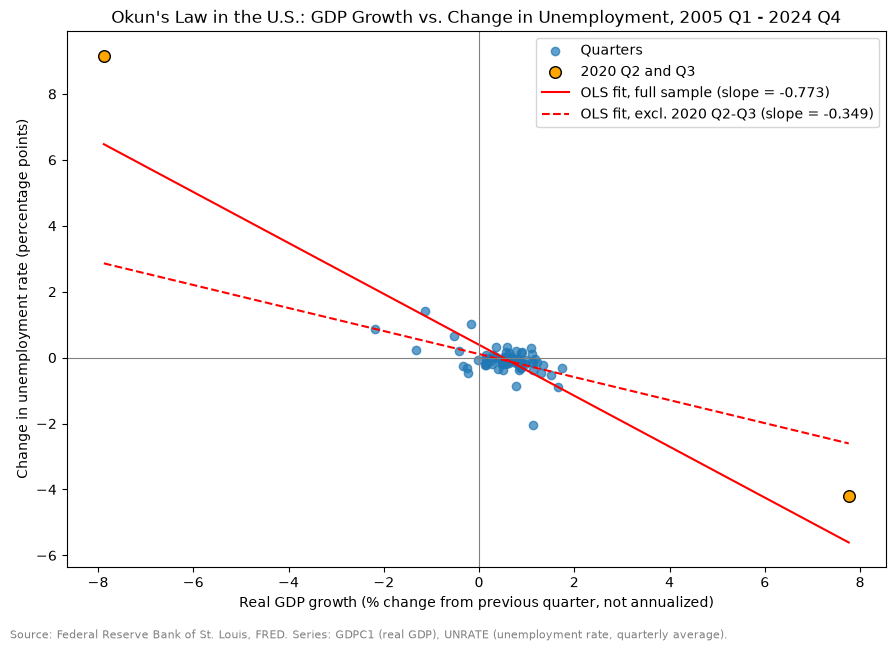

In [26]:
fig, ax = plt.subplots(figsize=(9, 6.5))

normal = df.drop(COVID_QUARTERS)
covid = df.loc[COVID_QUARTERS]
ax.scatter(normal["gdp_growth"], normal["d_unrate"], alpha=0.7, label="Quarters")
ax.scatter(covid["gdp_growth"], covid["d_unrate"], color="orange", edgecolor="black",
           s=70, zorder=3, label="2020 Q2 and Q3")

x = df["gdp_growth"].sort_values()
ax.plot(x, model.params["Intercept"] + model.params["gdp_growth"] * x, color="red",
        label=f"OLS fit, full sample (slope = {model.params['gdp_growth']:.3f})")
ax.plot(x, model_nc.params["Intercept"] + model_nc.params["gdp_growth"] * x, color="red",
        linestyle="--",
        label=f"OLS fit, excl. 2020 Q2-Q3 (slope = {model_nc.params['gdp_growth']:.3f})")

ax.axhline(0, color="gray", linewidth=0.8)
ax.axvline(0, color="gray", linewidth=0.8)
ax.set_title("Okun's Law in the U.S.: GDP Growth vs. Change in Unemployment, 2005 Q1 - 2024 Q4")
ax.set_xlabel("Real GDP growth (% change from previous quarter, not annualized)")
ax.set_ylabel("Change in unemployment rate (percentage points)")
ax.legend()
fig.text(0.01, 0.01,
         "Source: Federal Reserve Bank of St. Louis, FRED. Series: GDPC1 (real GDP), "
         "UNRATE (unemployment rate, quarterly average).",
         fontsize=8, color="gray", ha="left")
fig.tight_layout(rect=(0, 0.03, 1, 1))
fig.savefig("okun_scatter.png", dpi=150)
plt.show()

## 8. Results

The numbers below are from the run recorded in `results.txt`. FRED revises GDP data over time, so a later run may give slightly different values.

| Sample | Slope (b) | Std. error | p-value | R-squared | Quarters |
|---|---|---|---|---|---|
| Full sample | −0.773 | 0.044 | p < 0.001 | 0.795 | 80 |
| Without 2020 Q2 and Q3 | −0.349 | 0.063 | p < 0.001 | 0.289 | 78 |

**What the slope means:** In the full sample, a quarter with GDP growth 1 percentage point higher (for example 1.5% instead of 0.5%) is associated with an unemployment rate that falls by about **0.77 percentage points** more that quarter. Without the COVID quarters, the same 1-point difference is associated with about **0.35 percentage points** more of a drop. Because growth is measured per quarter, 1 percentage point of quarterly growth is a large difference, roughly 4 points at an annual rate.

**Effect of excluding 2020 Q2 and Q3:** These two quarters sit far from the other points and pull the fitted line steeply. Removing them:
- **Cuts the slope by more than half**, from −0.77 to −0.35.
- **Lowers R-squared from 0.80 to 0.29.** So most of the full sample's tight fit comes from those two quarters. Without those two quarters, GDP growth explains about 29% of the variation in unemployment changes.
- **Leaves the slope negative and statistically significant** (p < 0.001).

The −0.349 estimate is the result excluding 2020 Q2 and Q3. The relationship remains negative when those two quarters are left out.

## 9. Conclusion

The results **support the expectation and suggest Okun's Law still holds** in the U.S. from 2005 to 2024. In both regressions, faster GDP growth goes with falling unemployment, and the relationship is statistically significant.

**Association, not causation:** This regression shows that GDP growth and unemployment changes move together. It does not prove that GDP growth *causes* unemployment to fall. Causality could run both ways, since more people working also produces more output. Other factors, such as the business cycle, Federal Reserve policy, or shocks like COVID, can move both at once.

## 10. Limitations

This is a simple one-variable regression with standard (non-robust) standard errors. The p-values could be somewhat too small if the errors are correlated over time, and the Durbin-Watson statistic of 1.32 in the no-COVID regression hints at this. Statistical significance is based on conventional OLS standard errors; robustness to serial correlation has not been tested.